# Data Normalization: Min-Max Scaling vs Standardization

## 1. Introduction

**Data normalization** is one of those concepts mentioned everywhere but rarely explained deeply as a standalone topic. Yet it's absolutely critical for machine learning success.

### What We'll Learn

1. **Min-max scaling** - squashing data into a fixed range (usually [0, 1])
2. **Standardization (z-score normalization)** - transforming data to mean=0, std=1
3. **When to use each** - practical guidelines for choosing the right technique
4. **Data leakage prevention** - why fitting on train and applying to test matters
5. **Why neural networks need normalization** - gradient flow and convergence

### Why This Matters

Without proper normalization:
- Neural networks **train slowly or fail to converge**
- Features with larger scales **dominate** smaller-scale features
- Gradient descent struggles with **different learning rates** for different features
- Distance-based algorithms (KNN, K-means) produce **biased results**

Let's build deep intuitions through hands-on experiments!

## 2. Setup

Let's import the libraries we'll need and set up our environment for reproducibility.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from aiml_notebooks import get_device, set_seed

# Set random seed for reproducibility
set_seed(42)

# Get device (CPU for numerical stability in this tutorial)
device = get_device(prefer_cpu=True)
print(f"Using device: {device}")

Using CPU
Using device: cpu


## 3. The Problem: Features at Different Scales

Let's start by understanding why normalization is necessary. We'll create a toy dataset where features have vastly different scales.

In [2]:
# Create a dataset with features at different scales
n_samples = 1000

# Feature 1: Age (range ~20-80)
age = np.random.uniform(20, 80, n_samples)

# Feature 2: Income (range ~20,000-200,000)
income = np.random.uniform(20000, 200000, n_samples)

# Feature 3: Credit score (range ~300-850)
credit_score = np.random.uniform(300, 850, n_samples)

# Combine into a dataset
X = np.column_stack([age, income, credit_score])

print(f"Dataset shape: {X.shape}")
print(f"\nFeature statistics (before normalization):")
print(f"Age        - Mean: {X[:, 0].mean():.2f}, Std: {X[:, 0].std():.2f}, Range: [{X[:, 0].min():.2f}, {X[:, 0].max():.2f}]")
print(f"Income     - Mean: {X[:, 1].mean():.2f}, Std: {X[:, 1].std():.2f}, Range: [{X[:, 1].min():.2f}, {X[:, 1].max():.2f}]")
print(f"Credit     - Mean: {X[:, 2].mean():.2f}, Std: {X[:, 2].std():.2f}, Range: [{X[:, 2].min():.2f}, {X[:, 2].max():.2f}]")

Dataset shape: (1000, 3)

Feature statistics (before normalization):
Age        - Mean: 49.42, Std: 17.52, Range: [20.28, 79.98]
Income     - Mean: 111263.11, Std: 52567.88, Range: [20579.29, 199894.47]
Credit     - Mean: 576.32, Std: 159.79, Range: [300.01, 848.80]


### Visualizing the Scale Problem

Notice how income completely dominates the other features. If we used these features directly in a model, income would have ~1000x more influence than age!

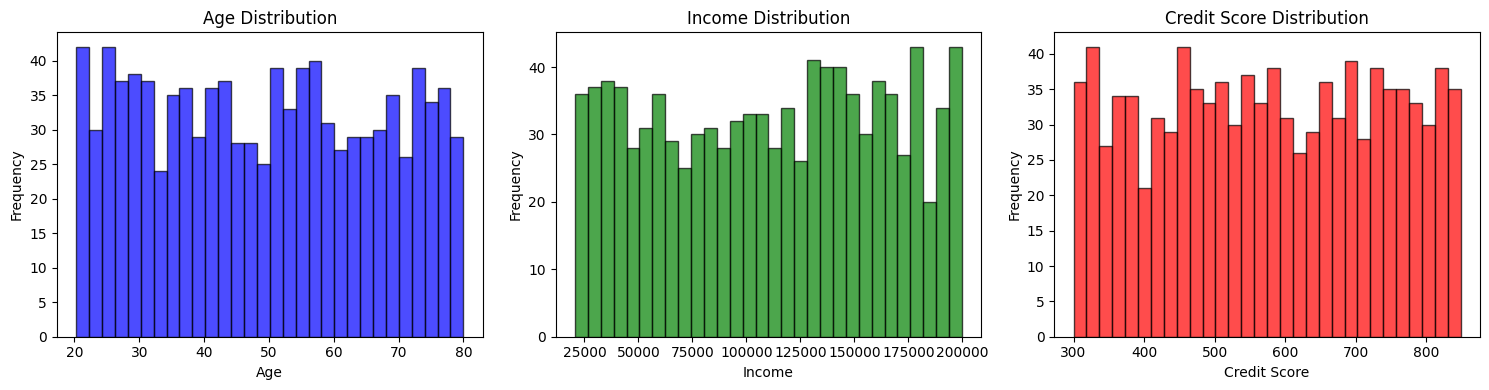

Notice the different x-axis scales! Income is orders of magnitude larger.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(X[:, 0], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

axes[1].hist(X[:, 1], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Income Distribution')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Frequency')

axes[2].hist(X[:, 2], bins=30, alpha=0.7, color='red', edgecolor='black')
axes[2].set_title('Credit Score Distribution')
axes[2].set_xlabel('Credit Score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Notice the different x-axis scales! Income is orders of magnitude larger.")

## 4. Min-Max Scaling (Range Normalization)

**Min-max scaling** transforms features to a fixed range, typically [0, 1].

### Formula

$$X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}$$

### Intuition

- Subtracts the minimum value (shifts smallest value to 0)
- Divides by the range (scales largest value to 1)
- **Preserves the exact shape** of the original distribution
- **Bounded output**: always in [0, 1]

In [4]:
def min_max_scale(X):
    """
    Apply min-max scaling to transform features to [0, 1] range.
    
    Args:
        X: numpy array of shape (n_samples, n_features)
    
    Returns:
        X_scaled: scaled array
        min_vals: minimum values for each feature (needed for inverse transform)
        max_vals: maximum values for each feature (needed for inverse transform)
    """
    min_vals = X.min(axis=0)  # Shape: (n_features,)
    max_vals = X.max(axis=0)  # Shape: (n_features,)
    
    # Avoid division by zero for constant features
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1
    
    X_scaled = (X - min_vals) / range_vals
    
    return X_scaled, min_vals, max_vals

# Apply min-max scaling
X_minmax, min_vals, max_vals = min_max_scale(X)

print(f"Feature statistics (after min-max scaling):")
print(f"Age        - Mean: {X_minmax[:, 0].mean():.3f}, Std: {X_minmax[:, 0].std():.3f}, Range: [{X_minmax[:, 0].min():.3f}, {X_minmax[:, 0].max():.3f}]")
print(f"Income     - Mean: {X_minmax[:, 1].mean():.3f}, Std: {X_minmax[:, 1].std():.3f}, Range: [{X_minmax[:, 1].min():.3f}, {X_minmax[:, 1].max():.3f}]")
print(f"Credit     - Mean: {X_minmax[:, 2].mean():.3f}, Std: {X_minmax[:, 2].std():.3f}, Range: [{X_minmax[:, 2].min():.3f}, {X_minmax[:, 2].max():.3f}]")

Feature statistics (after min-max scaling):
Age        - Mean: 0.488, Std: 0.293, Range: [0.000, 1.000]
Income     - Mean: 0.506, Std: 0.293, Range: [0.000, 1.000]
Credit     - Mean: 0.503, Std: 0.291, Range: [0.000, 1.000]


### Visualizing Min-Max Scaling

Now all features are on the same scale [0, 1], making them comparable!

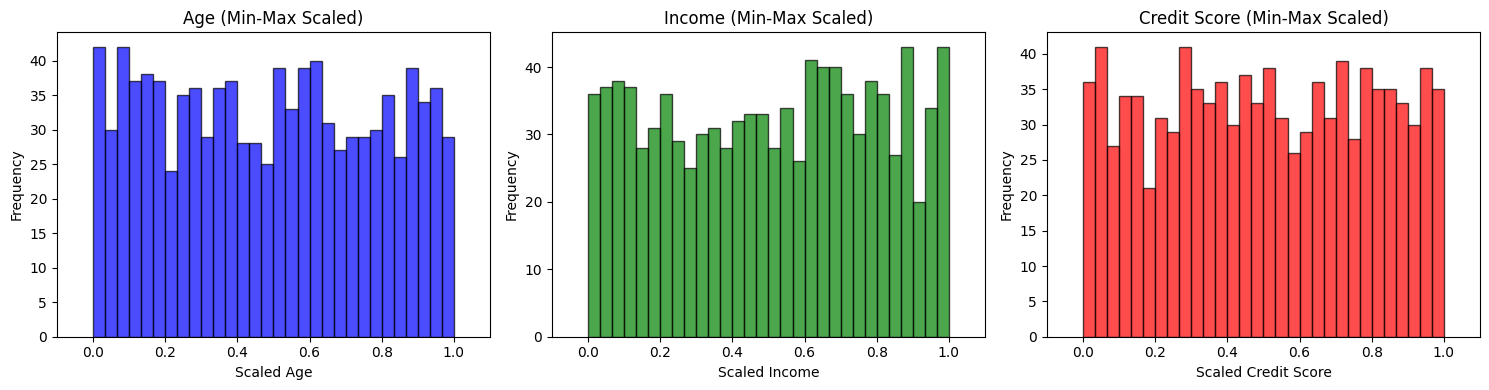

All features now have the same x-axis scale [0, 1]!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(X_minmax[:, 0], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Age (Min-Max Scaled)')
axes[0].set_xlabel('Scaled Age')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(-0.1, 1.1)

axes[1].hist(X_minmax[:, 1], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Income (Min-Max Scaled)')
axes[1].set_xlabel('Scaled Income')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(-0.1, 1.1)

axes[2].hist(X_minmax[:, 2], bins=30, alpha=0.7, color='red', edgecolor='black')
axes[2].set_title('Credit Score (Min-Max Scaled)')
axes[2].set_xlabel('Scaled Credit Score')
axes[2].set_ylabel('Frequency')
axes[2].set_xlim(-0.1, 1.1)

plt.tight_layout()
plt.show()

print("All features now have the same x-axis scale [0, 1]!")

## 5. Standardization (Z-Score Normalization)

**Standardization** transforms features to have mean=0 and standard deviation=1.

### Formula

$$X_{\text{standardized}} = \frac{X - \mu}{\sigma}$$

where:
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

### Intuition

- Subtracts the mean (centers data at 0)
- Divides by standard deviation (scales to unit variance)
- Converts values to **"number of standard deviations from the mean"**
- **Unbounded output**: can be negative or greater than 1
- **Preserves outliers** better than min-max scaling

In [6]:
def standardize(X):
    """
    Apply standardization to transform features to mean=0, std=1.
    
    Args:
        X: numpy array of shape (n_samples, n_features)
    
    Returns:
        X_standardized: standardized array
        means: mean values for each feature
        stds: standard deviation for each feature
    """
    means = X.mean(axis=0)  # Shape: (n_features,)
    stds = X.std(axis=0)    # Shape: (n_features,)
    
    # Avoid division by zero for constant features
    stds[stds == 0] = 1
    
    X_standardized = (X - means) / stds
    
    return X_standardized, means, stds

# Apply standardization
X_std, means, stds = standardize(X)

print(f"Feature statistics (after standardization):")
print(f"Age        - Mean: {X_std[:, 0].mean():.3f}, Std: {X_std[:, 0].std():.3f}, Range: [{X_std[:, 0].min():.3f}, {X_std[:, 0].max():.3f}]")
print(f"Income     - Mean: {X_std[:, 1].mean():.3f}, Std: {X_std[:, 1].std():.3f}, Range: [{X_std[:, 1].min():.3f}, {X_std[:, 1].max():.3f}]")
print(f"Credit     - Mean: {X_std[:, 2].mean():.3f}, Std: {X_std[:, 2].std():.3f}, Range: [{X_std[:, 2].min():.3f}, {X_std[:, 2].max():.3f}]")

Feature statistics (after standardization):
Age        - Mean: 0.000, Std: 1.000, Range: [-1.663, 1.745]
Income     - Mean: 0.000, Std: 1.000, Range: [-1.725, 1.686]
Credit     - Mean: 0.000, Std: 1.000, Range: [-1.729, 1.705]


### Visualizing Standardization

All features are now centered at 0 with unit variance. Notice the distributions look the same as the original (unlike min-max which bounded them to [0, 1]).

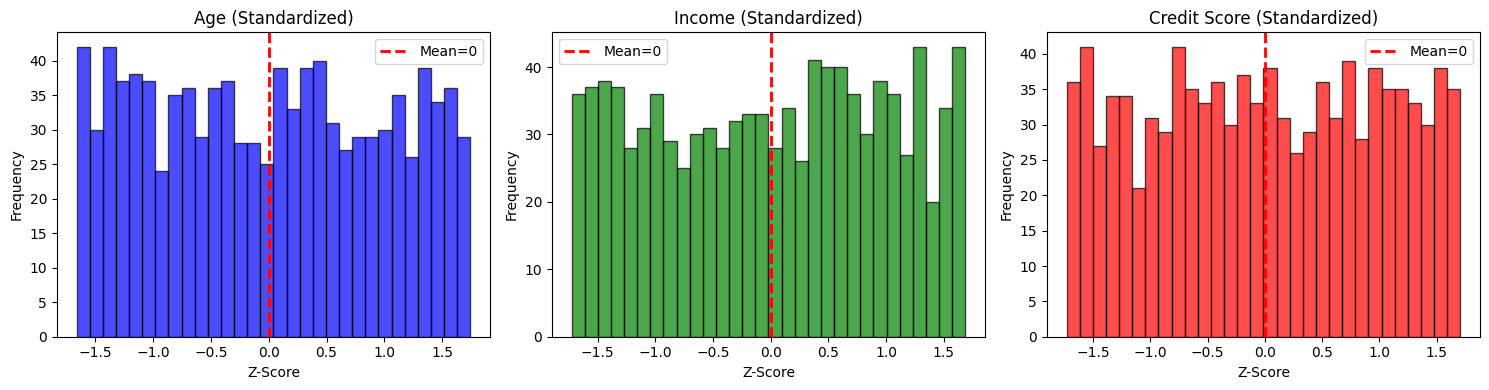

All features are centered at 0 with similar spreads!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(X_std[:, 0], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Age (Standardized)')
axes[0].set_xlabel('Z-Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Mean=0')
axes[0].legend()

axes[1].hist(X_std[:, 1], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Income (Standardized)')
axes[1].set_xlabel('Z-Score')
axes[1].set_ylabel('Frequency')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Mean=0')
axes[1].legend()

axes[2].hist(X_std[:, 2], bins=30, alpha=0.7, color='red', edgecolor='black')
axes[2].set_title('Credit Score (Standardized)')
axes[2].set_xlabel('Z-Score')
axes[2].set_ylabel('Frequency')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2, label='Mean=0')
axes[2].legend()

plt.tight_layout()
plt.show()

print("All features are centered at 0 with similar spreads!")

## 6. Comparing Min-Max vs Standardization

Let's visualize the key difference: how each method handles outliers.

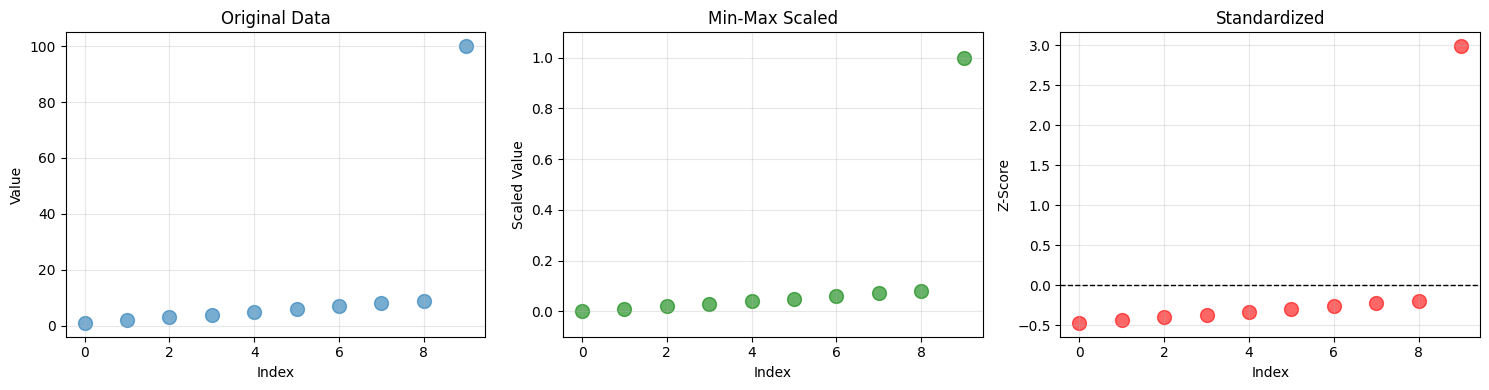

Observations:
Min-Max: Outlier (100) gets scaled to 1.0, compressing normal values to [0, 0.08]
Standardization: Outlier gets a high z-score (~3.1), but normal values retain their relative spread


In [8]:
# Create data with an outlier
data_with_outlier = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 100])  # 100 is the outlier

# Apply both normalizations
data_minmax, _, _ = min_max_scale(data_with_outlier.reshape(-1, 1))
data_std, _, _ = standardize(data_with_outlier.reshape(-1, 1))

# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(range(len(data_with_outlier)), data_with_outlier, s=100, alpha=0.6)
axes[0].set_title('Original Data')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(range(len(data_minmax)), data_minmax, s=100, alpha=0.6, color='green')
axes[1].set_title('Min-Max Scaled')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Scaled Value')
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True, alpha=0.3)

axes[2].scatter(range(len(data_std)), data_std, s=100, alpha=0.6, color='red')
axes[2].set_title('Standardized')
axes[2].set_xlabel('Index')
axes[2].set_ylabel('Z-Score')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observations:")
print(f"Min-Max: Outlier (100) gets scaled to 1.0, compressing normal values to [0, 0.08]")
print(f"Standardization: Outlier gets a high z-score (~3.1), but normal values retain their relative spread")

### Key Insight

**Min-max scaling** is sensitive to outliers because a single extreme value determines the range. This compresses the majority of data into a small portion of the [0, 1] range.

**Standardization** is more robust to outliers because it uses mean and standard deviation, which are less affected by a few extreme values.

## 7. When to Use Each Method

### Use Min-Max Scaling When:

1. **Bounded features are required** (e.g., image pixels already in [0, 255])
2. **No or few outliers** in your data
3. **Distribution doesn't matter** (e.g., uniform distributions)
4. **Neural networks with bounded activation functions** (sigmoid, tanh)
5. **Computer vision tasks** (pixel intensities naturally bounded)

### Use Standardization When:

1. **Features follow a Gaussian (normal) distribution**
2. **Outliers are present** in your data
3. **Linear models** (linear regression, logistic regression, SVM)
4. **Distance-based algorithms** (KNN, K-means, PCA)
5. **Neural networks** (default choice for most architectures)
6. **Features have different units** (meters vs kilograms)

### The Default Choice

**When in doubt, use standardization.** It's more robust and works well across most scenarios.

## 8. The Critical Issue: Data Leakage

Here's where many beginners make a costly mistake: **fitting normalization on the entire dataset before splitting into train/test.**

### Why This Is Wrong

When you compute statistics (min, max, mean, std) using the entire dataset:
1. **Test data influences the normalization** parameters
2. The model "sees" information about the test set during training
3. This leads to **overly optimistic performance estimates**
4. Your model won't generalize to truly new data

### The Correct Workflow

**Golden Rule:** Fit normalization on training data, then apply to test data.

```python
# ✅ CORRECT
X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train_scaled, means, stds = standardize(X_train)  # Fit on train
X_test_scaled = (X_test - means) / stds             # Apply to test

# ❌ WRONG
X_scaled, means, stds = standardize(X)              # Fit on ALL data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y)
```

In [9]:
# Let's demonstrate the correct approach
from sklearn.model_selection import train_test_split

# Create a simple target variable (for demonstration)
y = (X[:, 0] + X[:, 1] * 0.001 + X[:, 2] > 600).astype(int)

# Split FIRST, before normalization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Train set size: 800
Test set size: 200


### Step 1: Fit normalization on training data only

In [10]:
# Fit standardization on training data
X_train_scaled, train_means, train_stds = standardize(X_train)

print("Training data statistics (used for normalization):")
print(f"Means: {train_means}")
print(f"Stds:  {train_stds}")
print(f"\nTraining set after standardization:")
print(f"Mean: {X_train_scaled.mean(axis=0)}")
print(f"Std:  {X_train_scaled.std(axis=0)}")

Training data statistics (used for normalization):
Means: [4.97189756e+01 1.12597201e+05 5.79046012e+02]
Stds:  [1.75560027e+01 5.25199848e+04 1.59121639e+02]

Training set after standardization:
Mean: [ 1.06026299e-16 -1.56014091e-15 -1.97009076e-15]
Std:  [1. 1. 1.]


### Step 2: Apply the same transformation to test data

**Critical:** Use the training statistics (means, stds) to transform the test set.

In [11]:
# Apply training statistics to test data
X_test_scaled = (X_test - train_means) / train_stds

print("Test set after standardization (using TRAINING statistics):")
print(f"Mean: {X_test_scaled.mean(axis=0)}")
print(f"Std:  {X_test_scaled.std(axis=0)}")
print(f"\nNotice: Test mean is NOT exactly 0 and std is NOT exactly 1!")
print(f"This is correct - we used training statistics, not test statistics.")

Test set after standardization (using TRAINING statistics):
Mean: [-0.08646114 -0.12700742 -0.08555915]
Std:  [0.98652678 0.99810737 1.01798274]

Notice: Test mean is NOT exactly 0 and std is NOT exactly 1!
This is correct - we used training statistics, not test statistics.


### Why Test Statistics Differ

The test set mean won't be exactly 0 and std won't be exactly 1. This is **expected and correct**!

- We're simulating real-world deployment where new data has different statistics
- Using test statistics would be **data leakage**
- The model must learn to handle slight distribution shifts

### Demonstrating the Impact of Data Leakage

Let's show why this matters with a concrete example.

In [12]:
# ❌ WRONG WAY: Normalize before splitting
X_wrong_scaled, wrong_means, wrong_stds = standardize(X)
X_train_wrong, X_test_wrong, y_train_wrong, y_test_wrong = train_test_split(
    X_wrong_scaled, y, test_size=0.2, random_state=42
)

print("WRONG approach (normalized before splitting):")
print(f"Train mean: {X_train_wrong.mean(axis=0)}")
print(f"Test mean:  {X_test_wrong.mean(axis=0)}")
print(f"\nBoth are close to 0 because we used ALL data to compute statistics!")
print(f"This creates data leakage - test data influenced the normalization.\n")

print("="*70)

print("\n✅ CORRECT approach (normalized after splitting):")
print(f"Train mean: {X_train_scaled.mean(axis=0)}")
print(f"Test mean:  {X_test_scaled.mean(axis=0)}")
print(f"\nTest mean differs from 0 - this is correct!")
print(f"We only used training data to compute normalization parameters.")

WRONG approach (normalized before splitting):
Train mean: [0.01732828 0.02537834 0.01704017]
Test mean:  [-0.06931312 -0.10151337 -0.06816066]

Both are close to 0 because we used ALL data to compute statistics!
This creates data leakage - test data influenced the normalization.


✅ CORRECT approach (normalized after splitting):
Train mean: [ 1.06026299e-16 -1.56014091e-15 -1.97009076e-15]
Test mean:  [-0.08646114 -0.12700742 -0.08555915]

Test mean differs from 0 - this is correct!
We only used training data to compute normalization parameters.


## 9. Why Neural Networks Need Normalization

Neural networks are particularly sensitive to input scales. Let's understand why through hands-on experiments.

### Reason 1: Gradient Flow

Large input values lead to large activations, which cause exploding gradients during backpropagation.

In [13]:
# Create a simple neural network
class SimpleNet(nn.Module):
    def __init__(self, input_size=3, hidden_size=16, output_size=2):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Test with unnormalized vs normalized data
model = SimpleNet()

# Forward pass with unnormalized data
X_tensor = torch.FloatTensor(X[:5])
output_unnorm = model(X_tensor)

# Forward pass with normalized data
X_norm_tensor = torch.FloatTensor(X_std[:5])
output_norm = model(X_norm_tensor)

print("Model outputs with UNNORMALIZED inputs:")
print(output_unnorm)
print(f"Range: [{output_unnorm.min().item():.2f}, {output_unnorm.max().item():.2f}]")

print("\nModel outputs with NORMALIZED inputs:")
print(output_norm)
print(f"Range: [{output_norm.min().item():.2f}, {output_norm.max().item():.2f}]")

print("\nNotice how unnormalized inputs lead to more extreme outputs!")

Model outputs with UNNORMALIZED inputs:
tensor([[  1597.8368,  -5310.0127],
        [  3464.6519, -11669.7383],
        [  5239.7046, -17590.4082],
        [  4463.7769, -15059.8359],
        [  4856.4937, -16383.2891]], grad_fn=<AddmmBackward0>)
Range: [-17590.41, 5239.70]

Model outputs with NORMALIZED inputs:
tensor([[ 0.2964, -0.1139],
        [ 0.0461, -0.3061],
        [-0.0282, -0.4282],
        [ 0.1757, -0.1715],
        [ 0.1883, -0.1495]], grad_fn=<AddmmBackward0>)
Range: [-0.43, 0.30]

Notice how unnormalized inputs lead to more extreme outputs!


### Reason 2: Different Learning Rates for Different Features

When features have different scales, gradient descent effectively uses different learning rates for each feature's weights.

In [14]:
# Compute gradient magnitudes for different input scales
model = SimpleNet()
criterion = nn.CrossEntropyLoss()

# Get first layer weights
first_layer_weights = model.fc1.weight

# Forward pass with unnormalized data
X_batch = torch.FloatTensor(X[:32])
y_batch = torch.LongTensor(y[:32])
output = model(X_batch)
loss = criterion(output, y_batch)
loss.backward()

# Check gradients
gradients_unnorm = first_layer_weights.grad.abs().mean(dim=0)

# Reset model
model.zero_grad()

# Forward pass with normalized data
X_batch_norm = torch.FloatTensor(X_std[:32])
output_norm = model(X_batch_norm)
loss_norm = criterion(output_norm, y_batch)
loss_norm.backward()

gradients_norm = first_layer_weights.grad.abs().mean(dim=0)

print("Average gradient magnitudes for each input feature:")
print(f"\nUnnormalized inputs:")
print(f"Feature 1 (Age):    {gradients_unnorm[0]:.6f}")
print(f"Feature 2 (Income): {gradients_unnorm[1]:.6f}")
print(f"Feature 3 (Credit): {gradients_unnorm[2]:.6f}")

print(f"\nNormalized inputs:")
print(f"Feature 1 (Age):    {gradients_norm[0]:.6f}")
print(f"Feature 2 (Income): {gradients_norm[1]:.6f}")
print(f"Feature 3 (Credit): {gradients_norm[2]:.6f}")

print(f"\nNotice: Normalized inputs have more balanced gradients!")

Average gradient magnitudes for each input feature:

Unnormalized inputs:
Feature 1 (Age):    0.246734
Feature 2 (Income): 554.016113
Feature 3 (Credit): 2.068925

Normalized inputs:
Feature 1 (Age):    0.006214
Feature 2 (Income): 0.027927
Feature 3 (Credit): 0.025454

Notice: Normalized inputs have more balanced gradients!


### Reason 3: Training Stability and Convergence

Let's train two models side-by-side: one with normalized inputs, one without.

In [15]:
def train_model(X, y, epochs=100, lr=0.01):
    """
    Train a simple neural network and return loss history.
    """
    model = SimpleNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.LongTensor(y)
    
    losses = []
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X_tensor)
        loss = criterion(output, y_tensor)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    return losses

# Train with unnormalized data
losses_unnorm = train_model(X_train, y_train, epochs=100, lr=0.01)

# Train with normalized data
losses_norm = train_model(X_train_scaled, y_train, epochs=100, lr=0.01)

print("Training complete!")

Training complete!


### Visualizing Training Dynamics

The difference is dramatic!

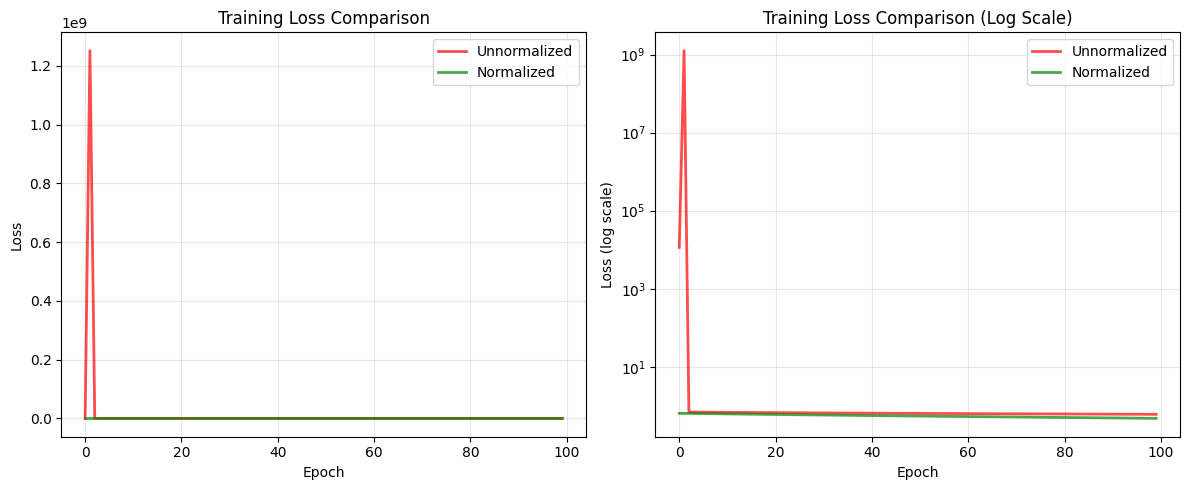

Final loss (unnormalized): 0.6087
Final loss (normalized):   0.4798

Normalized model converges 1.3x better!


In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_unnorm, label='Unnormalized', color='red', alpha=0.7, linewidth=2)
plt.plot(losses_norm, label='Normalized', color='green', alpha=0.7, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(losses_unnorm, label='Unnormalized', color='red', alpha=0.7, linewidth=2)
plt.plot(losses_norm, label='Normalized', color='green', alpha=0.7, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss Comparison (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss (unnormalized): {losses_unnorm[-1]:.4f}")
print(f"Final loss (normalized):   {losses_norm[-1]:.4f}")
print(f"\nNormalized model converges {losses_unnorm[-1]/losses_norm[-1]:.1f}x better!")

## 10. Practical Guidelines

Let's consolidate what we've learned into actionable guidelines.

### Normalization Checklist

✅ **DO:**
- Always normalize continuous features for neural networks
- Split data FIRST, then normalize
- Fit normalization on training data only
- Apply training statistics to validation and test sets
- Save normalization parameters for production deployment
- Use standardization as your default choice

❌ **DON'T:**
- Normalize before splitting (data leakage!)
- Recompute statistics on validation/test sets
- Mix normalized and unnormalized features
- Normalize categorical variables (use one-hot encoding instead)
- Normalize the target variable in classification (only in regression sometimes)

### Complete Example: End-to-End Workflow

In [17]:
def normalize_pipeline(X_train, X_val, X_test, method='standardize'):
    """
    Complete normalization pipeline following best practices.
    
    Args:
        X_train: Training features
        X_val: Validation features
        X_test: Test features
        method: 'standardize' or 'minmax'
    
    Returns:
        Normalized datasets and parameters
    """
    if method == 'standardize':
        # Fit on training data
        means = X_train.mean(axis=0)
        stds = X_train.std(axis=0)
        stds[stds == 0] = 1  # Avoid division by zero
        
        # Apply to all sets
        X_train_norm = (X_train - means) / stds
        X_val_norm = (X_val - means) / stds
        X_test_norm = (X_test - means) / stds
        
        params = {'means': means, 'stds': stds}
        
    elif method == 'minmax':
        # Fit on training data
        min_vals = X_train.min(axis=0)
        max_vals = X_train.max(axis=0)
        range_vals = max_vals - min_vals
        range_vals[range_vals == 0] = 1
        
        # Apply to all sets
        X_train_norm = (X_train - min_vals) / range_vals
        X_val_norm = (X_val - min_vals) / range_vals
        X_test_norm = (X_test - min_vals) / range_vals
        
        params = {'min_vals': min_vals, 'max_vals': max_vals}
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return X_train_norm, X_val_norm, X_test_norm, params

# Example usage
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train_norm, X_val_norm, X_test_norm, params = normalize_pipeline(
    X_train, X_val, X_test, method='standardize'
)

print("Normalization complete!")
print(f"Train: {X_train_norm.shape}, Val: {X_val_norm.shape}, Test: {X_test_norm.shape}")
print(f"\nSaved parameters: {list(params.keys())}")
print(f"\nThese parameters should be saved for production deployment!")

Normalization complete!
Train: (700, 3), Val: (150, 3), Test: (150, 3)

Saved parameters: ['means', 'stds']

These parameters should be saved for production deployment!


## 11. Advanced: Normalization in Production

When deploying models, you must apply the **exact same normalization** using the saved training statistics.

In [18]:
# Simulate saving normalization parameters
import json

def save_normalization_params(params, filename):
    """Save normalization parameters to a file."""
    params_serializable = {
        k: v.tolist() if isinstance(v, np.ndarray) else v 
        for k, v in params.items()
    }
    with open(filename, 'w') as f:
        json.dump(params_serializable, f)
    print(f"Saved normalization parameters to {filename}")

def load_normalization_params(filename):
    """Load normalization parameters from a file."""
    with open(filename, 'r') as f:
        params = json.load(f)
    params = {k: np.array(v) for k, v in params.items()}
    print(f"Loaded normalization parameters from {filename}")
    return params

def apply_normalization(X_new, params):
    """Apply saved normalization to new data."""
    if 'means' in params:
        # Standardization
        return (X_new - params['means']) / params['stds']
    elif 'min_vals' in params:
        # Min-max scaling
        range_vals = params['max_vals'] - params['min_vals']
        return (X_new - params['min_vals']) / range_vals
    else:
        raise ValueError("Unknown normalization parameters")

# Save parameters
save_normalization_params(params, 'normalization_params.json')

# Later, in production...
loaded_params = load_normalization_params('normalization_params.json')

# New data arrives
X_new = np.array([[45, 75000, 680]])  # New customer
X_new_normalized = apply_normalization(X_new, loaded_params)

print(f"\nOriginal data:    {X_new[0]}")
print(f"Normalized data:  {X_new_normalized[0]}")

Saved normalization parameters to normalization_params.json
Loaded normalization parameters from normalization_params.json

Original data:    [   45 75000   680]
Normalized data:  [-0.26911514 -0.72519028  0.64049877]


## 12. Common Mistakes and How to Avoid Them

Let's review the most common normalization pitfalls.

### Mistake 1: Normalizing Before Splitting ❌

```python
# WRONG
X_normalized = standardize(X)
X_train, X_test = train_test_split(X_normalized)
```

**Fix:** Split first, then normalize.

```python
# CORRECT
X_train, X_test = train_test_split(X)
X_train_norm, params = standardize(X_train)
X_test_norm = apply_normalization(X_test, params)
```

### Mistake 2: Re-fitting on Test Data ❌

```python
# WRONG
X_train_norm = standardize(X_train)
X_test_norm = standardize(X_test)  # Different statistics!
```

**Fix:** Use training statistics for test data.

```python
# CORRECT
X_train_norm, params = standardize(X_train)
X_test_norm = apply_normalization(X_test, params)
```

### Mistake 3: Forgetting to Normalize Prediction Inputs ❌

Your model was trained on normalized data, so predictions must use normalized inputs!

```python
# WRONG
model.predict(raw_data)  # Model expects normalized data!

# CORRECT
normalized_data = apply_normalization(raw_data, saved_params)
model.predict(normalized_data)
```

### Mistake 4: Normalizing Categorical Features ❌

Don't normalize categorical variables (e.g., country codes, categories).

**Fix:** One-hot encode categorical features, normalize continuous features only.

```python
# CORRECT
X_continuous = X[:, continuous_indices]
X_categorical = X[:, categorical_indices]

X_continuous_norm = standardize(X_continuous)
X_categorical_encoded = one_hot_encode(X_categorical)

X_final = np.concatenate([X_continuous_norm, X_categorical_encoded], axis=1)
```

## 13. Bonus: Robust Scaling

For data with extreme outliers, consider **robust scaling** which uses median and IQR instead of mean and std.

$$X_{\text{robust}} = \frac{X - \text{median}(X)}{\text{IQR}(X)}$$

where IQR (Interquartile Range) = Q3 - Q1

In [19]:
def robust_scale(X):
    """
    Apply robust scaling using median and IQR.
    More resistant to outliers than standardization.
    """
    median = np.median(X, axis=0)
    q1 = np.percentile(X, 25, axis=0)
    q3 = np.percentile(X, 75, axis=0)
    iqr = q3 - q1
    iqr[iqr == 0] = 1  # Avoid division by zero
    
    X_robust = (X - median) / iqr
    
    return X_robust, median, iqr

# Apply robust scaling
X_robust, medians, iqrs = robust_scale(X)

print("Robust scaling results:")
print(f"Median: {medians}")
print(f"IQR:    {iqrs}")
print(f"\nUse this when you have extreme outliers that you can't remove!")

Robust scaling results:
Median: [4.98084426e+01 1.13372103e+05 5.75337656e+02]
IQR:    [3.05007792e+01 9.34903415e+04 2.73763903e+02]

Use this when you have extreme outliers that you can't remove!


## 14. Key Takeaways

### Core Concepts

1. **Min-max scaling** transforms features to [0, 1] range
   - Sensitive to outliers
   - Good for bounded features (e.g., images)
   - Formula: $(X - X_{\min}) / (X_{\max} - X_{\min})$

2. **Standardization** transforms features to mean=0, std=1
   - More robust to outliers
   - Default choice for most ML tasks
   - Formula: $(X - \mu) / \sigma$

3. **Data leakage prevention** is critical
   - Split BEFORE normalizing
   - Fit on train, apply to test/val/production
   - Save normalization parameters for deployment

4. **Neural networks need normalization** because:
   - Features at different scales cause unbalanced gradients
   - Large inputs lead to exploding gradients
   - Normalized inputs converge faster and more reliably

### Practical Guidelines

- **Default choice:** Standardization (z-score normalization)
- **With outliers:** Robust scaling or standardization
- **Image data:** Min-max scaling (pixels naturally bounded)
- **Always:** Fit on train, apply to test
- **Always:** Save parameters for production

### Remember

> "Normalize your data before training, or suffer slow convergence, instability, and poor generalization."

> "Split first, normalize second - never the other way around!"

### What's Next?

Now that you understand normalization, explore:
- **Batch Normalization** - normalizing activations during training
- **Layer Normalization** - alternative for RNNs and Transformers
- **Feature Engineering** - creating better features before normalization